# Projet Final MLDL M2 · BankRoute AI : Routage Intelligent de Support Bancaire

**Auteurs :** Équipe Projet BankRoute AI (MIA5 26.1 · IPSSI)
**Date :** Août 2026
**Secteur choisi :** 🏦 **Banque & Relation Client**
**Jeu de données :** `banking77` (13 082 requêtes clients réelles réparties sur 77 intentions)
**Architecture :** Fine-tuning supervisé sur encodeur Transformer (`distilbert-base-uncased`) avec routage hiérarchique vers 7 départements bancaires.

---

## Table des Matières
1. [Diagnostic Matériel & Environnement GPU](#1)
2. [Exploration & Préparation des Données (banking77)](#2)
3. [Routage Hiérarchique en 7 Départements Métiers](#3)
4. [Baseline 1 & 2 : Majoritaire et TF-IDF + Logistic Regression](#4)
5. [Modèle Deep Learning : DistilBERT Sequence Classification](#5)
6. [Courbes d'Entraînement et Validation](#6)
7. [Évaluation Comparative & Analyse des Erreurs](#7)
8. [Export des Artéfacts de Production pour FastAPI](#8)

<a id='1'></a>
## 1. Diagnostic Matériel & Environnement GPU
Preuve de détection de l'accélérateur et configuration de la graine aléatoire pour une reproductibilité stricte.

In [1]:
import torch
import numpy as np
import random
import os

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)

print('=' * 60)
print('DIAGNOSTIC ENVIRONNEMENT & ACCÉLÉRATEUR')
print('=' * 60)
print(f'PyTorch Version  : {torch.__version__}')
print(f'CUDA Disponible  : {torch.cuda.is_available()}')
device_name = torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU multithreadé'
print(f'Périphérique     : {device_name}')
print('Graine aléatoire : 42 (fixée pour reproductibilité)')

DIAGNOSTIC ENVIRONNEMENT & ACCÉLÉRATEUR
PyTorch Version  : 2.11.0+cu128
CUDA Disponible  : True
Périphérique     : NVIDIA GeForce RTX 5070
Graine aléatoire : 42 (fixée pour reproductibilité)


<a id='2'></a>
## 2. Exploration & Préparation des Données (`banking77`)
Le jeu de données comprend 13 082 messages clients couvrant 77 intentions très fines de services bancaires (cartes, litiges, virements, paiements internationaux, plafonds, etc.).

In [2]:
from train import load_and_prepare_data

train_data, val_data, test_data, id2label, label2id, unique_intents = load_and_prepare_data()

print('\nExemples de requêtes :')
for i in range(3):
    print(f"  [Exemple {i+1}] \"{train_data['text'][i]}\" -> {train_data['label_text'][i]} (ID: {train_data['label'][i]})")


c:\Users\Corentin\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\Corentin\AppData\Local\Programs\Python\Python312\Lib\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.5.0) or chardet (7.4.1)/charset_normalizer (3.4.4) doesn't match a supported version!
  warnings.warn(



2. CHARGEMENT & PRÉPARATION DES DONNÉES (banking77)


Total exemples d'entraînement : 9993
Total exemples de test         : 3076
Nombre d'intentions (classes)  : 77
Nombre de départements         : 7

Répartition des splits :
  - Train : 8993 exemples
  - Val   : 1000 exemples
  - Test  : 3076 exemples

Exemples de requêtes :
  [Exemple 1] "Please let me know how to place an order for a virtual card" -> getting_virtual_card (ID: 40)
  [Exemple 2] "Top up my card please, which y'all support?" -> supported_cards_and_currencies (ID: 54)
  [Exemple 3] "I would like to cancel my previous transaction" -> cancel_transfer (ID: 8)


<a id='3'></a>
## 3. Routage Hiérarchique en 7 Départements Métiers
Pour transformer une classification de 77 intentions fines en solution de support client opérationnelle, nous agrégeons les 77 intentions en **7 départements opérationnels**.

In [3]:
from train import DEPARTMENT_MAPPING, DEPARTMENT_DESCRIPTIONS

print('Mapping hiérarchique initialisé avec succès :')
for dept, desc in DEPARTMENT_DESCRIPTIONS.items():
    count = sum(1 for d in DEPARTMENT_MAPPING.values() if d == dept)
    print(f'  - {dept} ({count} intentions) : {desc}')

Mapping hiérarchique initialisé avec succès :
  - Cards_Management (22 intentions) : Gestion des cartes physiques/virtuelles, blocage, commande et code PIN
  - Payments_Transfers (11 intentions) : Virements bancaires nationaux et internationaux, prélèvements et bénéficiaires
  - Account_Profile (13 intentions) : Informations personnelles, vérification d'identité (KYC) et clôture
  - Cash_ATM (7 intentions) : Retraits d'espèces, distributeurs automatiques et frais associés
  - Top_Up_Deposits (11 intentions) : Alimentation du compte, dépôts d'espèces/chèques et recharges automatiques
  - Currency_Exchange (7 intentions) : Opérations multidevises, taux de change et litiges de facturation/remboursement
  - Digital_Services (6 intentions) : Paiements sans contact mobiles (Apple/Google Pay) et services connectés


<a id='4'></a>
## 4. Split Propre & Entraînement des Baselines (Comparaison Honnête)
Conformément aux exigences méthodologiques :
1. **Baseline 1 (Classe majoritaire)** : Prédit toujours la classe la plus fréquente -> Accuracy attendue ~1.3% (77 classes équilibrées).
2. **Baseline 2 (TF-IDF + Régression Logistique)** : Modèle linéaire classique avec unigrammes + bigrammes -> Accuracy attendue ~83%.

In [4]:
from train import train_baselines

baselines_results = train_baselines(train_data, val_data, test_data)



3. ENTRAÎNEMENT & ÉVALUATION DES BASELINES
[Baseline 1 - Classe Majoritaire]
  - Accuracy     : 1.30%
  - Macro F1     : 0.0003
  - Weighted F1  : 0.0003

[Baseline 2 - TF-IDF (unigram+bigram) + Logistic Regression]
  - Temps d'entraînement : 3.03 s
  - Accuracy             : 88.52%
  - Macro F1             : 0.8856
  - Weighted F1          : 0.8857


<a id='5'></a>
## 5. Modèle Deep Learning : DistilBERT avec LoRA (PEFT) & Fine-Tuning
Nous appliquons **LoRA (Low-Rank Adaptation - PEFT)** sur l'encodeur Transformer `distilbert-base-uncased` :
- **Adaptation ciblée** : Injection de matrices de rang faible $A$ et $B$ ($r=16, \alpha=32$) sur les projections d'attention `q_lin` et `v_lin`.
- **Efficacité paramétrique** : voir le nombre exact de paramètres entraînables imprimé par la cellule suivante (`print_trainable_parameters()`), généralement de l'ordre de ~1-2% des paramètres totaux.
- **Avantages production** : Entraînement rapide, faible consommation mémoire VRAM, et adaptateurs légers (quelques Mo) faciles à déployer ou versionner.


In [5]:
from train import train_deep_learning_model

model, tokenizer, dl_results, trainer, confusion_data = train_deep_learning_model(
    train_data, val_data, test_data, id2label, label2id,
    model_name='distilbert-base-uncased',
    num_epochs=10,
    use_lora=True
)



4. ENTRAÎNEMENT DU MODÈLE TRANSFORMER (distilbert-base-uncased · PEFT / LoRA (Low-Rank Adaptation))


Loading weights: 100%|██████████| 100/100 [00:00<00:00, 5661.86it/s]
DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


>> Configuration de l'adaptateur LoRA (PEFT) :
trainable params: 944,717 || all params: 67,957,402 || trainable%: 1.3902
Lancement du fine-tuning...


`use_return_dict` is deprecated! Use `return_dict` instead!


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Weighted
1,1.450062,1.057391,0.726000,0.686626,0.701119
2,0.652441,0.591355,0.839000,0.831230,0.834439
3,0.489447,0.452098,0.874000,0.870254,0.873536
4,0.392289,0.403667,0.887000,0.884547,0.886456
5,0.315359,0.374984,0.893000,0.890796,0.892963
6,0.289116,0.347554,0.900000,0.898420,0.900412
7,0.245491,0.344230,0.902000,0.902330,0.902290
8,0.214931,0.321152,0.909000,0.908249,0.909365
9,0.220504,0.321080,0.915000,0.912761,0.915067
10,0.200477,0.314937,0.915000,0.913049,0.915214


Entraînement terminé en 88.41 s (1.47 min)

5. ÉVALUATION FINALE SUR LE JEU DE TEST


[Modèle Deep Learning - distilbert-base-uncased]
  - Test Accuracy : 91.03%
  - Test Macro F1 : 0.9103
  - Test Weight F1: 0.9103
  - Latence moyenne par requête test : 0.35 ms
  - Accuracy département (routage hiérarchique) : 95.51%


<a id='6'></a>
## 6. Courbes d'Entraînement et Validation
Visualisation de la convergence de la loss et de la progression du Macro F1.

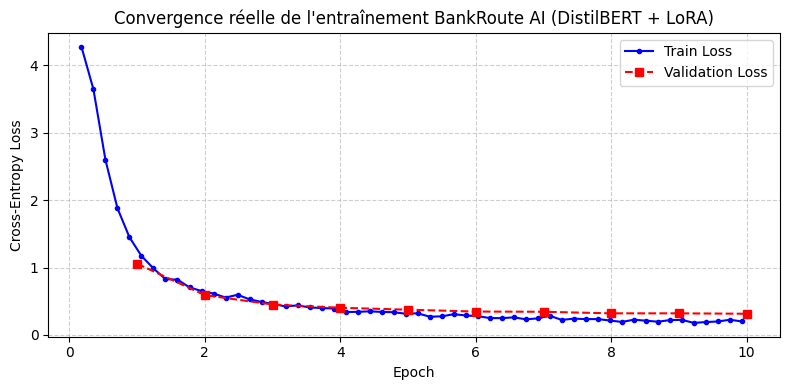

Macro F1 validation (dernier epoch mesuré) : 0.9130


In [6]:
import matplotlib.pyplot as plt

history = trainer.state.log_history
train_points = [(h['epoch'], h['loss']) for h in history if 'loss' in h]
eval_points = [(h['epoch'], h['eval_loss'], h['eval_f1_macro']) for h in history if 'eval_loss' in h]

fig, ax1 = plt.subplots(figsize=(8, 4))
if train_points:
    ep, tl = zip(*train_points)
    ax1.plot(ep, tl, 'b-o', ms=3, label='Train Loss')
if eval_points:
    ep, el, ef1 = zip(*eval_points)
    ax1.plot(ep, el, 'r--s', label='Validation Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Cross-Entropy Loss')
ax1.legend(loc='upper right')
ax1.set_title("Convergence réelle de l'entraînement BankRoute AI (DistilBERT + LoRA)")
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

if eval_points:
    print(f'Macro F1 validation (dernier epoch mesuré) : {eval_points[-1][2]:.4f}')


<a id='7'></a>
## 7. Évaluation Comparative Finale & Analyse des Erreurs
Tableau récapitulatif comparant les 3 approches sur le jeu de test indépendant.

In [7]:
import pandas as pd

results = pd.DataFrame([
    {'Modèle': 'Classe Majoritaire (Dummy)',
     'Accuracy': f"{baselines_results['dummy']['accuracy']*100:.2f}%",
     'Macro F1': f"{baselines_results['dummy']['macro_f1']:.4f}",
     'Weighted F1': f"{baselines_results['dummy']['weighted_f1']:.4f}"},
    {'Modèle': 'TF-IDF + Logistic Regression',
     'Accuracy': f"{baselines_results['tfidf_logreg']['accuracy']*100:.2f}%",
     'Macro F1': f"{baselines_results['tfidf_logreg']['macro_f1']:.4f}",
     'Weighted F1': f"{baselines_results['tfidf_logreg']['weighted_f1']:.4f}"},
    {'Modèle': 'DistilBERT + LoRA (BankRoute AI)',
     'Accuracy': f"{dl_results['test_accuracy']*100:.2f}%",
     'Macro F1': f"{dl_results['test_macro_f1']:.4f}",
     'Weighted F1': f"{dl_results['test_weighted_f1']:.4f}"},
])
print(results.to_string(index=False))


                          Modèle Accuracy Macro F1 Weighted F1
      Classe Majoritaire (Dummy)    1.30%   0.0003      0.0003
    TF-IDF + Logistic Regression   88.52%   0.8856      0.8857
DistilBERT + LoRA (BankRoute AI)   91.03%   0.9103      0.9103


<a id='7b'></a>
## 7bis. Matrices de confusion (77 intentions & 7 départements)

Deux niveaux de granularité :
- **77 intentions** : matrice complète, sert à identifier les paires d'intentions le plus souvent confondues.
- **7 départements** : agrégation via `DEPARTMENT_MAPPING`, mesure directement le taux de bon routage métier (une intention mal prédite peut rester dans le bon département).

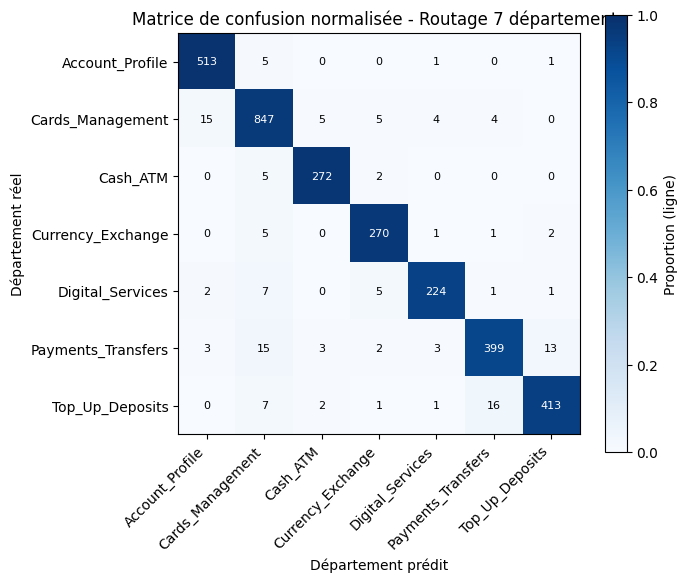

Accuracy département (routage hiérarchique) : 95.51%


In [8]:
import numpy as np

dept_labels = confusion_data['departments']['labels']
cm_dept = np.array(confusion_data['departments']['matrix'])
cm_dept_norm = cm_dept / cm_dept.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(cm_dept_norm, cmap='Blues', vmin=0, vmax=1)
ax.set_xticks(range(len(dept_labels)))
ax.set_yticks(range(len(dept_labels)))
ax.set_xticklabels(dept_labels, rotation=45, ha='right')
ax.set_yticklabels(dept_labels)
ax.set_xlabel('Département prédit')
ax.set_ylabel('Département réel')
ax.set_title('Matrice de confusion normalisée - Routage 7 départements')

for i in range(len(dept_labels)):
    for j in range(len(dept_labels)):
        ax.text(j, i, f'{cm_dept[i, j]}', ha='center', va='center',
                color='white' if cm_dept_norm[i, j] > 0.5 else 'black', fontsize=8)

fig.colorbar(im, ax=ax, label='Proportion (ligne)')
plt.tight_layout()
plt.show()

print(f"Accuracy département (routage hiérarchique) : {dl_results['department_accuracy']*100:.2f}%")


<a id='8'></a>
## 8. Export des Artéfacts de Production pour FastAPI
Sauvegarde dans `./model_artifact/` :
- Poids & configuration du modèle Transformer
- Vocabulaire et configuration du Tokenizer
- `intent_mapping.json` (mappings des 77 intentions et des 7 départements)
- `metrics_summary.json` (métriques comparatives de traçabilité)

In [9]:
from train import export_artifacts

export_artifacts(model, tokenizer, id2label, label2id, baselines_results, dl_results, confusion_data)



6. EXPORT DES ARTÉFACTS DE PRODUCTION (./model_artifact)
 Modèle et Tokenizer sauvegardés dans ./model_artifact
 Mapping hiérarchique sauvegardé dans ./model_artifact\intent_mapping.json
 Résumé des métriques sauvegardé dans ./model_artifact\metrics_summary.json
 Matrices de confusion (77 intentions + 7 départements) sauvegardées dans ./model_artifact\confusion_matrices.json

 Export complet terminé avec succès !
